# Project 3 Assignment

## Assignment Overview & Instructions

The objective of project 3 is to perform keyword network analysis and word frequency
analysis.  
Please complete the following 7 tasks in this assessment, using the instructions indicated below.   

**Note:** You may create your own custom functions if necessary to complete the tasks.

### Task 1: Import the Dataset for use in your Notebook.   

You can find the source dataset [here](https://drive.google.com/file/d/1YJe45YXo0xSkFClGPBhKYLzupFEyGadK/view?usp=sharing)

The dataset was imported using pandas and loaded into a DataFrame.  Each row represents an individual academic article. The dataset contains a total of 13 columns, including one column for the article title and 12 columns for associated keywords which will be used to analyze co-ooccurrence patterns between research topics.

In [1]:
## YOUR CODE HERE
import pandas as pd

df = pd.read_csv('/Users/wiktorialasek/Desktop/Project3_6400_WiktoriaLasek/data/keywords_data.csv')

df.head()

,Title,Keyword 1,Keyword 2,Keyword 3,Keyword 4,Keyword 5,Keyword 6,Keyword 7,Keyword 8,Keyword 9,Keyword 10,Keyword 11,Keyword 12
0,Feb/03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Meta-Analyses of Financial Performance and Equ...,EQUITY,ORGANIZATIONAL sociology,PERFORMANCE,META-analysis,PSYCHOMETRICS,ORGANIZATIONAL research,FINANCIAL performance,AGENCY theory,ORGANIZATIONAL effectiveness,ORGANIZATIONAL behavior,CORPORATE governance,NaN
3,"Home Country Environments, Corporate Diversifi...",DIVERSIFICATION in industry,BUSINESS planning,PERFORMANCE standards,EMPLOYEES -- Rating of,CORPORATE culture,STRATEGIC planning,ORGANIZATIONAL effectiveness,MANAGEMENT science,MANAGEMENT research,PRODUCT management,NaN,NaN
4,Safeguarding Investments in Asymmetric Interor...,INTERORGANIZATIONAL relations,INTERGROUP relations,BUSINESS communication,INVESTMENTS,SUPPLY chains,KNOWLEDGE management,INTERORGANIZATIONAL networks,CORPORATE governance,GROUP decision making,INTELLECTUAL capital,NaN,NaN


### **Task 2:**  Write a Python code to extract keyword data from the above file. 
Write a Python code to extract keyword data from the above file and convert it to a weighted adjacency matrix. See the figure below to understand the process

![Task Two - Adjacency matrix](Task%202%20-%20Figure%201.png)

In this step, the keyword data is extracted and prepared for analysis. The title  column is removed. The remaining keyword columns are converted into a list of lists, where each inner list represents the keywords of a single article.

A nested loop is used to iterate through each article and its keywords. The `isinstance()` function is applied to ensure that only valid string values are processed, which helps exclude missing values. Each keyword is then converted to lowercase.

In [2]:
## YOUR CODE HERE
keyword_data = df.drop(columns=['Title'],errors='ignore')
docs = keyword_data.values.tolist()


docs_lower = []

for doc in docs:
    clean_doc = []
    for keyword in doc:
        if isinstance(keyword, str):
            clean_doc.append(keyword.lower())
    docs_lower.append(clean_doc)

In [3]:
docs_lower

[[],
 [],
 ['equity',
  'organizational sociology',
  'performance',
  'meta-analysis',
  'psychometrics',
  'organizational research',
  'financial performance',
  'agency theory',
  'organizational effectiveness',
  'organizational behavior',
  'corporate governance'],
 ['diversification in industry',
  'business planning',
  'performance standards',
  'employees -- rating of',
  'corporate culture',
  'strategic planning',
  'organizational effectiveness',
  'management science',
  'management research',
  'product management'],
 ['interorganizational relations',
  'intergroup relations',
  'business communication',
  'investments',
  'supply chains',
  'knowledge management',
  'interorganizational networks',
  'corporate governance',
  'group decision making',
  'intellectual capital'],
 ['executive compensation',
  'wages',
  'human capital',
  'labor economics',
  'personnel management',
  'management science',
  'contingency theory (management)',
  'compensation management',
  

Below, keyword co-occurrence pairs are generated for each article. A list comprehension is used to create all possible pairs of keywords within each document, ensuring that each keyword is paired with every other keyword that appears in the same article. Each pair is duplicated in reverse order. The pairs from all documents are then flattened into a single list. The `FreqDist` function is used to count how frequently each keyword pair appears across all articles, resulting in a weighted co-occurrence structure.

In [4]:
import nltk

co_occurrence_pairs = []

for doc in docs_lower:
    pairs= [(doc[i], doc[j]) for i in range (len(doc)) for j in range (i+1, len(doc))]

    symetric_pairs = pairs + [(b,a) for (a,b) in pairs]

    co_occurrence_pairs.append(symetric_pairs)


all_pairs = sum(co_occurrence_pairs, [])

weighted_co_occurrences = nltk.FreqDist(all_pairs)
weighted_co_occurrences


FreqDist({('organizational effectiveness', 'organizational behavior'): 11, ('organizational behavior', 'organizational effectiveness'): 11, ('organizational behavior', 'organizational structure'): 9, ('organizational structure', 'organizational behavior'): 9, ('personnel management', 'organizational behavior'): 8, ('organizational behavior', 'personnel management'): 8, ('management science', 'organizational behavior'): 7, ('organizational behavior', 'management science'): 7, ('organizational sociology', 'organizational behavior'): 6, ('organizational behavior', 'corporate governance'): 6, ...})

 In this step, the weighted co-occurrence data is used to construct an adjacency matrix representing they keyword network. First, a set of unique keywords is created by iterating through the co-occurrence pairs and extracting all unique words. The set of keywords is then sorted and a square adjacency matrix is initialized using a pandas DataFrame where both rows and columns represent the unique keywords. Finally, the co-occurrence weights are inserted into the matrix.

In [5]:
keywords = set()

for (word1, word2), weight in weighted_co_occurrences.items():
    if isinstance(word1, str) and isinstance(word2, str):
        keywords.add(word1)
        keywords.add(word2)

keywords = sorted(keywords)

adj_matrix = pd.DataFrame(0, index=keywords, columns=keywords)

for (word1, word2), weight in weighted_co_occurrences.items():
    adj_matrix.loc[word1, word2] = weight
    adj_matrix.loc[word2, word1] = weight


adj_matrix


,agency theory,aggression (psychology),ambivalence,anger in the workplace,behavioral research,boards of directors,break-even analysis,burnout (psychology),business communication,business enterprises,...,violence in the workplace,wage payment systems,wages,women -- employment,women employees,work & family,work attitudes,work environment,work environment -- psychological aspects,workflow
agency theory,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aggression (psychology),0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,1,2,0,0
ambivalence,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
anger in the workplace,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,1,0,0
behavioral research,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
work & family,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
work attitudes,0,1,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
work environment,0,2,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
work environment -- psychological aspects,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### **Task 3:**  Read the adjacency matrix and convert it into a weighted network

In this step, the adjacency matrix is converted into a weighted network graph using the NetworkX library. The function `nx.from_pandas_adjacency()` is used to automatically transform the matrix into a graph structure, where each node represents a unique keyword and each edge represents a co-occurrence relationship between two keywords. 
The number of nodes represents the total unique keywords in the dataset, while the number of edges represents the number of unique keyword co-occurrence relationships. 
The resulting network contains 248 nodes and 2141 edges.


In [6]:
## YOUR CODE HERE
import networkx as nx

G = nx.from_pandas_adjacency(adj_matrix)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


Number of nodes: 248
Number of edges: 2141


### **Task 4:**  Compute node degree and strength

In the code below, the degree of each keyword is calculated using the NetworkX graph. The degree represents the number of unique connections a keyword has with other keywords in the network. The degree values are extracted from the graph and converted into a dictionary, where each keyword is associated with its degree. The dictionary is then transformed into a pandas DataFrame which is sorted in descending order.
The results show that keyword "organizational behaviour" has the highest degree (166), indicating that it is highly connected to many other keywords. In contrast, "high technology industries" has the lowest degree (4).

In [7]:
## YOUR CODE HERE
degree = pd.DataFrame(list(dict(G.degree()).items()), columns=['keyword', 'degree'])
degree = degree.sort_values('degree', ascending=False).reset_index(drop=True).reset_index(drop=True)
degree


,keyword,degree
0,organizational behavior,166
1,organizational effectiveness,104
2,management science,102
3,personnel management,93
4,decision making,90
...,...,...
243,eminent domain,8
244,cross-cultural differences,7
245,stewards,7
246,taiwanese,7


In the code below, the strength of each keyword is calculated. It represents the total weight of all connections associated with a keyword, meaning it reflects how frequently a keyword co-occurs with others in dataset. The strength values are obtained using the weighted degree of each node in the NetworkX graph. These values are stored in a dictionary and then converted into a pandas DataFrame. The DataFrame is sorted in descending order to identify the most influential keywords based on co-occurrence frequency.
The results indicate that "organizational behaviour" has the highest strength (265), showing that it frequently co-occurs with many other keywords. In contrast, "high technology industries" has the lowest strength (4), indicating limited co-occurrence with other topics.

In [8]:
strength = pd.DataFrame(list(dict(G.degree(weight='weight')).items()), columns=['keyword', 'strength'])
strength = strength.sort_values('strength', ascending=False).reset_index(drop=True)
strength

,keyword,strength
0,organizational behavior,265
1,organizational effectiveness,144
2,management science,136
3,personnel management,126
4,decision making,112
...,...,...
243,strategic alliances (business),8
244,taiwanese,7
245,cross-cultural differences,7
246,stewards,7


### **Task 5:**  Show the top 10 nodes by degree and top 10 nodes by strength

In this step, the top 10 keywords are indentified based on both degree and strength. The highest-ranking keywords were selected by taking the first 10 entries from the sorted DataFrames. The results show that several keywords, such as organizational behaviour, organizational effectiveness, and management science, rank highly in both degree and strength. 

In [9]:
## YOUR CODE HERE
degree_top_ten = degree.head(10).reset_index(drop=True)
strength_top_ten = strength.head(10).reset_index(drop=True)


In [10]:
degree_top_ten

,keyword,degree
0,organizational behavior,166
1,organizational effectiveness,104
2,management science,102
3,personnel management,93
4,decision making,90
5,organizational structure,74
6,organizational sociology,66
7,strategic planning,66
8,industrial management,64
9,corporate governance,62


In [11]:
strength_top_ten

,keyword,strength
0,organizational behavior,265
1,organizational effectiveness,144
2,management science,136
3,personnel management,126
4,decision making,112
5,organizational structure,107
6,organizational sociology,96
7,corporate governance,85
8,industrial management,84
9,strategic planning,80


### **Task 6:** Show the top 10 node pairs by weight

In this step, keyword pairs and their co-occurrence frequencies are analyzed to identify the strongest relationships in the network. The weighted co-occurrence dictionary is first converted into a pandas DataFrame, where each row represents a pair of keywords and their corresponding co-occurrence count.

In [12]:
pairs_df = pd.DataFrame([(word1, word2, weight) for (word1, word2), weight in weighted_co_occurrences.items()], columns = ['keyword1', 'keyword2', 'weight'])
pairs_df

,keyword1,keyword2,weight
0,equity,organizational sociology,1
1,equity,performance,1
2,equity,meta-analysis,1
3,equity,psychometrics,1
4,equity,organizational research,1
...,...,...,...
4277,customer orientation,decision making,1
4278,marketing strategy,decision making,1
4279,customer orientation,customer satisfaction,1
4280,marketing strategy,customer satisfaction,1


Duplicate pairs such as (a, b) and (b, a) are removed by keeping only one ordered version of each pair. This ensures that each keyword relationship is counted only once.



In [13]:
## YOUR CODE HERE
pairs_df = pairs_df[pairs_df['keyword1'] < pairs_df['keyword2']]
pairs_df

,keyword1,keyword2,weight
0,equity,organizational sociology,1
1,equity,performance,1
2,equity,meta-analysis,1
3,equity,psychometrics,1
4,equity,organizational research,1
...,...,...,...
4274,customer orientation,organizational behavior,1
4275,marketing strategy,organizational behavior,1
4276,customer satisfaction,decision making,1
4277,customer orientation,decision making,1


The pairs are then sorted in descending order based on their weights, and the top 10 pairs are selected. These top pairs represent the most frequently co-occurring keywords, highlighting the strongest thematic connections within the dataset.

In [14]:
pairs_df = pairs_df.sort_values('weight', ascending=False).reset_index(drop=True)
pairs_df

,keyword1,keyword2,weight
0,organizational behavior,organizational effectiveness,11
1,organizational behavior,organizational structure,9
2,organizational behavior,personnel management,8
3,management science,organizational behavior,7
4,decision making,organizational behavior,6
...,...,...,...
2136,interorganizational relations,organizational effectiveness,1
2137,interorganizational relations,organizational behavior,1
2138,quality of products,self-perception,1
2139,organizational behavior,self-perception,1


In [15]:
top_ten_pairs = pairs_df.head(10).reset_index(drop=True)
top_ten_pairs

,keyword1,keyword2,weight
0,organizational behavior,organizational effectiveness,11
1,organizational behavior,organizational structure,9
2,organizational behavior,personnel management,8
3,management science,organizational behavior,7
4,decision making,organizational behavior,6
5,organizational effectiveness,organizational structure,6
6,corporate governance,organizational behavior,6
7,organizational behavior,organizational sociology,6
8,organizational sociology,teams in the workplace,5
9,industrial management,organizational behavior,5


### **Task 7:** Plot strength on y-axis and degree on x-axis

In this step, the relationship between degree and strength is analyzed using a scatter plot. The degree and strength DataFrames are first merged based on the keyword to ensure that both metrics correspond to the same nodes.

In [16]:
## YOUR CODE HERE
degree_strength_df = pd.merge(degree, strength, on='keyword')
degree_strength_df

,keyword,degree,strength
0,organizational behavior,166,265
1,organizational effectiveness,104,144
2,management science,102,136
3,personnel management,93,126
4,decision making,90,112
...,...,...,...
243,eminent domain,8,8
244,cross-cultural differences,7,7
245,stewards,7,7
246,taiwanese,7,7


A scatter plot is then created, where each point represents a keyword. The x-axis shows the degree (number of connections), and the y-axis shows the strength (total co-occurrence frequency). A linear trend line is added using a best-fit model to better visualize the relationship between the two variables.
The resulting plot shows a clear positive relationship between degree and strength, forming an approximately diagonal trend. This indicates that keywords with more connections tend to also have higher co-occurrence frequencies. In other words, highly connected keywords are also more influential within the network.

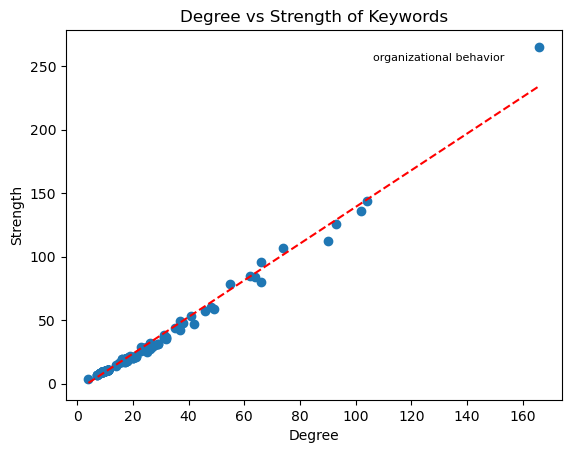

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.scatter(degree_strength_df['degree'], degree_strength_df['strength'])

m, b = np.polyfit(degree_strength_df['degree'], degree_strength_df['strength'], 1)
x_line = np.linspace(degree_strength_df['degree'].min(), degree_strength_df['degree'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linestyle='--', label='Trend line')

ob = degree_strength_df[degree_strength_df['keyword'] == 'organizational behavior'].iloc[0]
plt.annotate('organizational behavior', xy=(ob['degree'], ob['strength']), xytext=(-120, -10),  textcoords='offset points',fontsize=8)


plt.xlabel('Degree')
plt.ylabel('Strength')
plt.title('Degree vs Strength of Keywords')

plt.show()

## Submitting your Project

Once you've completed your project, it's time to submit your work for grading.   
This week, you will submit your code file `Project 3.ipynb` to the following Staff Graded Assignment for review.  

In order to submit your work, please follow the steps below:
1. Verify you've saved your work using the `Save` button within the Jupyter Notebook 
2. Download this notebook using the `File` -> `Download As` -> Choose the `Notebook (.ipynb)` format.
3. Access the following Step 2: Submit Project 3 item.
4. Complete all prompted fields, and upload your Jupyter Notebook file (Project 3.ipynb) in the indicated field.
5. Submit your notebook to "Step 2: Submit Project 3" by the deadline indicated within your course view for the Project 3 Assignment item.

Congratulations on completing the Project 3 Assignment!